# 04c: ARIMAX & SARIMAX Models

## Objective
Train ARIMAX and SARIMAX models with exogenous features for enhanced forecasting.

## Models
- ARIMAX (ARIMA with exogenous variables)
- SARIMAX (Seasonal ARIMA with exogenous variables)

## Requirements
- Feature-engineered data from notebook 03 (`features_for_arimax.csv`)


## GPU Acceleration (Optional)

**This notebook benefits significantly from GPU acceleration for LSTM training!**

### GPU Benefits:
- **LSTM training:** GPU provides 10-50x speedup for deep learning models
- ARIMA/SARIMA auto-tuning is computationally intensive
- VAR model training benefits from parallel processing
- GPU can reduce total training time from 15-20 minutes to 3-5 minutes

### Note:
- **CPU works fine** but will be slower (especially for LSTM)
- LSTM on CPU: ~10-15 minutes vs ~1-2 minutes on GPU
- If GPU is unavailable, CPU runtime is perfectly acceptable




## Install Dependencies (if needed)

If packages are missing, install them here.


In [15]:
# ============================================================================
# PROJECT CONFIGURATION
# ============================================================================
import os

# Setup paths - mount Google Drive if not already mounted (matching notebook 03)
DRIVE_MOUNTED = False
DRIVE_DATA_PROCESSED = None
DRIVE_MODELS_PATH = None
DRIVE_RESULTS_PATH = None

try:
    from google.colab import drive
    # Check if drive is already mounted
    if os.path.exists('/content/drive'):
        DRIVE_MOUNTED = True
        print("✓ Google Drive already mounted")
    else:
        # Mount Google Drive
        print("📁 Mounting Google Drive...")
        drive.mount('/content/drive')
        DRIVE_MOUNTED = True
        print("✓ Google Drive mounted successfully")

    # Set up Google Drive paths
    if DRIVE_MOUNTED:
        DRIVE_ROOT = '/content/drive/MyDrive/hospital_admissions_forecasting'
        DRIVE_DATA_PROCESSED = os.path.join(DRIVE_ROOT, 'data', 'processed')
        DRIVE_MODELS_PATH = os.path.join(DRIVE_ROOT, 'models')
        DRIVE_RESULTS_PATH = os.path.join(DRIVE_ROOT, 'results', 'visualizations', 'model_development')
        os.makedirs(DRIVE_DATA_PROCESSED, exist_ok=True)
        os.makedirs(DRIVE_MODELS_PATH, exist_ok=True)
        os.makedirs(DRIVE_RESULTS_PATH, exist_ok=True)
        print(f"✓ Google Drive paths configured: {DRIVE_ROOT}")
except ImportError:
    print("ℹ️  Not running in Google Colab (will only check local paths)")
except Exception as e:
    print(f"⚠️  Could not mount Google Drive: {e}")
    print("   Will continue with local Colab paths only")

# Local Colab paths
PROJECT_ROOT = '/content/hospital_admissions_forecasting'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
DATA_RAW = os.path.join(DATA_DIR, 'raw')
DATA_PROCESSED = os.path.join(DATA_DIR, 'processed')
MODELS_PATH = os.path.join(PROJECT_ROOT, 'models')
RESULTS_PATH = os.path.join(PROJECT_ROOT, 'results', 'visualizations', 'model_development')

for path in [DATA_RAW, DATA_PROCESSED, MODELS_PATH, RESULTS_PATH]:
    os.makedirs(path, exist_ok=True)

# Helper function to save files to both local and Google Drive (matching notebook 03)
def save_file(data, filename, local_path, drive_path=None, **kwargs):
    """
    Save file to both local and Google Drive (if available).

    Args:
        data: Data to save (DataFrame, dict, model, etc.)
        filename: Name of the file
        local_path: Local directory path
        drive_path: Google Drive directory path (optional)
        **kwargs: Additional arguments for save methods (e.g., index=False for to_csv)
    """
    # Save to local
    local_file = os.path.join(local_path, filename)
    if isinstance(data, pd.DataFrame):
        data.to_csv(local_file, **kwargs)
    elif isinstance(data, (dict, list)) and filename.endswith('.json'):
        import json
        with open(local_file, 'w') as f:
            json.dump(data, f, **kwargs)
    elif filename.endswith('.pkl'):
        import pickle
        with open(local_file, 'wb') as f:
            pickle.dump(data, f)
    elif hasattr(data, 'save'):
        data.save(local_file)
    else:
        # Fallback: try to write as text
        with open(local_file, 'w') as f:
            f.write(str(data))
    print(f"✓ Saved to local: {local_file}")

    # Save to Google Drive if available
    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if isinstance(data, pd.DataFrame):
                data.to_csv(drive_file, **kwargs)
            elif isinstance(data, (dict, list)) and filename.endswith('.json'):
                import json
                with open(drive_file, 'w') as f:
                    json.dump(data, f, **kwargs)
            elif filename.endswith('.pkl'):
                import pickle
                with open(drive_file, 'wb') as f:
                    pickle.dump(data, f)
            elif hasattr(data, 'save'):
                data.save(drive_file)
            else:
                with open(drive_file, 'w') as f:
                    f.write(str(data))
            print(f"✓ Saved to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save to Google Drive: {e}")

# Helper function to save plots to both locations (matching notebook 02)
def save_plot(fig, filename, local_path, drive_path=None, **kwargs):
    """Save plot to both local and Google Drive."""
    local_file = os.path.join(local_path, filename)
    fig.savefig(local_file, **kwargs)
    print(f"✓ Saved plot to local: {local_file}")

    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            fig.savefig(drive_file, **kwargs)
            print(f"✓ Saved plot to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save plot to Google Drive: {e}")

# Helper function to load file from multiple locations (matching notebook 03)
def load_file(filename, local_path, drive_path=None):
    """
    Load file from local or Google Drive (local priority).

    Returns:
        Loaded data or None if not found
    """
    # Try local first
    local_file = os.path.join(local_path, filename)
    if os.path.exists(local_file):
        if filename.endswith('.csv'):
            return pd.read_csv(local_file, index_col=0, parse_dates=True)
        elif filename.endswith('.pkl'):
            import pickle
            with open(local_file, 'rb') as f:
                return pickle.load(f)
        elif filename.endswith('.json'):
            import json
            with open(local_file, 'r') as f:
                return json.load(f)
        elif filename.endswith('.h5'):
            from tensorflow import keras
            return keras.models.load_model(local_file)

    # Try Google Drive if available
    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if os.path.exists(drive_file):
                if filename.endswith('.csv'):
                    return pd.read_csv(drive_file, index_col=0, parse_dates=True)
                elif filename.endswith('.pkl'):
                    import pickle
                    with open(drive_file, 'rb') as f:
                        return pickle.load(f)
                elif filename.endswith('.json'):
                    import json
                    with open(drive_file, 'r') as f:
                        return json.load(f)
                elif filename.endswith('.h5'):
                    from tensorflow import keras
                    return keras.models.load_model(drive_file)
        except Exception as e:
            print(f"⚠️  Could not load from Google Drive: {e}")

    return None


✓ Google Drive already mounted
✓ Google Drive paths configured: /content/drive/MyDrive/hospital_admissions_forecasting


In [16]:
try:
    import pmdarima
    print("✓ pmdarima is already installed")
except ImportError:
    print("Installing pmdarima...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pmdarima"])
    print("✓ pmdarima installed successfully")
    import pmdarima
try:
    import tensorflow
    print("✓ tensorflow is already installed")
except ImportError:
    print("Installing tensorflow...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow"])
    print("✓ tensorflow installed successfully")


✓ pmdarima is already installed
✓ tensorflow is already installed


## KPI Forecasting with VAR Models

We will also develop VAR (Vector Autoregression) models to forecast multiple KPIs simultaneously:
- Daily admissions (primary)
- Daily discharges
- Bed occupancy rates
- This demonstrates advanced methodology and shows relationships between operational metrics


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import random
warnings.filterwarnings('ignore')

# Try to import tqdm for progress bars (optional)
try:
    from tqdm import tqdm
    TQDM_AVAILABLE = True
except ImportError:
    TQDM_AVAILABLE = False
    # Create a simple progress bar fallback
    class tqdm:
        def __init__(self, iterable=None, total=None, desc=None, unit=None, ncols=None):
            self.iterable = iterable
            self.total = total or (len(iterable) if iterable else None)
            self.desc = desc or ""
            self.unit = unit or "it"
            self.current = 0
            self.last_print = 0

        def __enter__(self):
            if self.desc:
                print(f"{self.desc}...", end="", flush=True)
            return self

        def __exit__(self, *args):
            print()  # New line after completion

        def __iter__(self):
            if self.iterable is None:
                return self
            for item in self.iterable:
                yield item
                self.update(1)

        def update(self, n=1):
            self.current += n
            if self.total:
                pct = (self.current / self.total) * 100
                # Print every 10% or every 100 items
                if pct - self.last_print >= 10 or (self.current % 100 == 0 and self.current > 0):
                    print(f"\r{self.desc}: {self.current}/{self.total} ({pct:.1f}%)", end="", flush=True)
                    self.last_print = pct
                if self.current >= self.total:
                    print()  # New line when complete
            else:
                if self.current % 100 == 0:
                    print(f"\r{self.desc}: {self.current} {self.unit}", end="", flush=True)

        def set_description(self, desc):
            self.desc = desc

# Set random seed for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ============================================================================
# PERFORMANCE OPTIMIZATION CONFIGURATION
# ============================================================================
# Optimized for Google Colab T4 GPU - faster training with minimal accuracy loss

# Configuration
TRAIN_TEST_SPLIT = 0.8

# ARIMA/SARIMA configuration - OPTIMIZED for speed and volatility capture
ARIMA_MIN_P = 1  # Minimum AR terms (start from 1 for better reactivity)
ARIMA_MIN_Q = 4  # Minimum MA terms (start from 1 for better error capture)
ARIMA_MAX_P = 2  # Reduced from 5 (faster search, less smoothing for volatility)
ARIMA_MAX_Q = 5  # Reduced from 5 (still reactive to spikes)
ARIMA_N_JOBS = -1  # Use all CPU cores
ARIMA_USE_APPROXIMATION = True  # Faster but less precise
ARIMA_MAX_ORDER = 8  # Reduced from 12 (faster search)
ARIMA_MAX_ITER = 10  # Reduced from 15 (faster convergence)

# SARIMA configuration - OPTIMIZED for speed and volatility capture
SARIMA_MIN_P = 1  # Minimum AR terms (start from 1 for better reactivity)
SARIMA_MIN_Q = 4  # Minimum MA terms (start from 1 for better error capture)
SARIMA_MAX_P = 2  # Keep at 2 (already constrained for speed)
SARIMA_MAX_Q = 5  # Keep at 2 (already constrained for speed)
SARIMA_MIN_P_SEASONAL = 0  # Seasonal AR can start from 0
SARIMA_MIN_Q_SEASONAL = 0  # Seasonal MA can start from 0
SARIMA_MAX_P_SEASONAL = 1  # Keep at 1 (weekly seasonality)
SARIMA_MAX_Q_SEASONAL = 1  # Keep at 1 (weekly seasonality)
SARIMA_MAX_ORDER = 6  # Keep at 6 (already constrained)
SARIMA_N_JOBS = -1
SARIMA_USE_APPROXIMATION = True  # Faster search
SARIMA_MAX_ITER = 10  # Limit iterations for speed

# VAR configuration - OPTIMIZED for speed
VAR_MAX_LAGS = 3  # Reduced from 5 (faster lag selection)
VAR_IC = 'aic'  # Use AIC (faster than testing multiple ICs)
VAR_WINDOW_SIZE = 7  # Smaller windows (7 days) for better daily variation capture
VAR_RETRAIN_FREQUENCY = 30  # Retrain more frequently (every 30 days) to adapt to changes
VAR_SKIP_GRANGER = True  # Skip Granger causality tests (saves ~30 seconds)

# ARIMAX/SARIMAX configuration - ROLLING WINDOW FORECASTING WITH HYBRID RETRAINING
ARIMAX_WINDOW_SIZE = 7  # Smaller windows (7 days) for better daily variation capture
# Hybrid retraining: Fixed intervals + Error-based triggers
ARIMAX_BASE_RETRAIN_FREQUENCY = 21  # Base retraining frequency (every 3 weeks)
ARIMAX_ERROR_THRESHOLD = 1.5  # Retrain early if error > 1.5x historical average
ARIMAX_EARLY_RETRAIN_THRESHOLD = 7  # Minimum days between retrains (even if error high)
ARIMAX_FAST_RETRAIN = True  # Use fast refitting instead of full search (10x faster)
SARIMAX_WINDOW_SIZE = 7  # Smaller windows (7 days) for better daily variation capture
# Hybrid retraining: Fixed intervals + Error-based triggers
SARIMAX_BASE_RETRAIN_FREQUENCY = 21  # Base retraining frequency (every 3 weeks)
SARIMAX_ERROR_THRESHOLD = 1.5  # Retrain early if error > 1.5x historical average
SARIMAX_EARLY_RETRAIN_THRESHOLD = 7  # Minimum days between retrains (even if error high)
SARIMAX_FAST_RETRAIN = True  # Use fast refitting instead of full search (10x faster)

# LSTM configuration - OPTIMIZED for speed
LSTM_ARCHITECTURE_SEARCH = False  # Skip architecture search (use standard)
LSTM_BATCH_SIZE_SEARCH = False  # Skip batch size search (use 32)
LSTM_BATCH_SIZE = 32  # Fixed batch size
LSTM_MAX_EPOCHS = 30  # Reduced for speed (early stopping will stop earlier)
LSTM_EARLY_STOPPING_PATIENCE = 5  # Stop sooner
LSTM_SEQUENCE_LENGTH = 30  # Keep at 30
LSTM_VALIDATION_SPLIT = 0.2

print("⚡ Performance Optimization: ENABLED (Fast Mode)")
print(f"  ARIMA: Fixed order (1, 0, 5), maxiter={ARIMA_MAX_ITER}")
print(f"  SARIMA: Fixed order (1, 0, 5) x (0, 0, 1, 7), maxiter={SARIMA_MAX_ITER}")
print(f"  VAR: max_lags={VAR_MAX_LAGS}, IC={VAR_IC.upper()}, skip_granger={VAR_SKIP_GRANGER}")
print(f"  LSTM: architecture_search={LSTM_ARCHITECTURE_SEARCH}, batch_size={LSTM_BATCH_SIZE}, max_epochs={LSTM_MAX_EPOCHS}, patience={LSTM_EARLY_STOPPING_PATIENCE}")
print(f"  Retraining: hybrid approach (base={ARIMAX_BASE_RETRAIN_FREQUENCY} days, error threshold={ARIMAX_ERROR_THRESHOLD}x, min interval={ARIMAX_EARLY_RETRAIN_THRESHOLD} days)")
print(f"  Fast refitting enabled (10x faster)")
print("  Expected training time: ~1-2 minutes")

# Import ARIMA/SARIMA
from statsmodels.tsa.arima.model import ARIMA
try:
    import pmdarima as pm
    PMDARIMA_AVAILABLE = True
except ImportError:
    PMDARIMA_AVAILABLE = False
    print("⚠️  pmdarima not available - ARIMA/SARIMA auto-tuning will be skipped")
    print("   Install with: pip install pmdarima")

# Import VAR
from statsmodels.tsa.api import VAR

# Import TensorFlow for LSTM
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
    from sklearn.preprocessing import MinMaxScaler
    TENSORFLOW_AVAILABLE = True
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"🚀 GPU detected: {len(gpus)} GPU(s) available")
        print(f"   GPU: {gpus[0].name}")
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            tf.random.set_seed(RANDOM_SEED)
        except RuntimeError as e:
            print(f"   Note: {e}")
    else:
        print("💻 Using CPU for LSTM training (GPU not available)")
        print("   Note: GPU acceleration recommended for faster LSTM training")
        tf.random.set_seed(RANDOM_SEED)
except ImportError:
    TENSORFLOW_AVAILABLE = False
    print("⚠️  TensorFlow not available - LSTM model will be skipped")
    print("   Install with: pip install tensorflow")

# Baseline forecast functions
def naive_forecast(train_data, horizon):
    """Naive forecast: use the last observed value."""
    if isinstance(train_data, pd.Series):
        last_value = train_data.iloc[-1]
    else:
        last_value = train_data[-1]
    return np.full(horizon, last_value)

def seasonal_naive_forecast(train_data, horizon, season_length=7):
    """Seasonal naive forecast: use value from same period in previous season."""
    if len(train_data) < season_length:
        return naive_forecast(train_data, horizon)
    forecasts = []
    for i in range(horizon):
        idx = len(train_data) - season_length + (i % season_length)
        if isinstance(train_data, pd.Series):
            forecasts.append(train_data.iloc[idx])
        else:
            forecasts.append(train_data[idx])
    return np.array(forecasts)

def moving_average_forecast(train_data, horizon, window=7):
    """Moving average forecast: use average of last N periods."""
    if len(train_data) < window:
        return naive_forecast(train_data, horizon)
    if isinstance(train_data, pd.Series):
        avg = np.mean(train_data.iloc[-window:])
    else:
        avg = np.mean(train_data[-window:])
    return np.full(horizon, avg)

# VAR model functions
def train_var_model(kpi_dataframe, maxlags=7, ic='aic'):
    """Train a VAR model on multiple KPIs."""
    var_model = VAR(kpi_dataframe)
    var_fitted = var_model.fit(maxlags=maxlags, ic=ic, verbose=False)
    return var_fitted

def forecast_var(var_model, steps=30, last_obs=None):
    """Generate forecasts from a fitted VAR model."""
    if last_obs is None:
        last_obs = var_model.y[-var_model.k_ar:]

    # Convert to numpy array and ensure correct shape
    if isinstance(last_obs, pd.DataFrame):
        last_obs = last_obs.values
    last_obs = np.array(last_obs)

    # Ensure we have enough observations (at least k_ar)
    if last_obs.shape[0] < var_model.k_ar:
        raise ValueError(f"Insufficient observations for VAR forecast: need at least {var_model.k_ar}, got {last_obs.shape[0]}")

    # Use only the last k_ar observations
    if last_obs.shape[0] > var_model.k_ar:
        last_obs = last_obs[-var_model.k_ar:]

    # Ensure 2D shape (k_ar, n_vars)
    if last_obs.ndim == 1:
        last_obs = last_obs.reshape(-1, len(var_model.names))

    forecast = var_model.forecast(last_obs, steps=steps)
    return forecast

# Multi-step optimization functions removed - using AIC-based optimization only

print(f"⚡⚡ FAST TRAINING MODE ENABLED (~1-2 minutes)")
print(f"   - Fixed ARIMA order: (1, 0, 5) for speed and volatility capture")
print(f"   - Fixed SARIMA order: (1, 0, 5) x (0, 0, 1, 7) for speed and volatility capture")
print(f"   - Limited iterations (maxiter={ARIMA_MAX_ITER}) for speed")
print(f"   - Fast retraining: refit with same orders - 10x faster than full search")
print(f"   - Hybrid retraining: base={ARIMAX_BASE_RETRAIN_FREQUENCY} days, error threshold={ARIMAX_ERROR_THRESHOLD}x, min interval={ARIMAX_EARLY_RETRAIN_THRESHOLD} days")
print(f"   - LSTM: max_epochs={LSTM_MAX_EPOCHS}, patience={LSTM_EARLY_STOPPING_PATIENCE}")
print()


⚡ Performance Optimization: ENABLED (Fast Mode)
  ARIMA: Fixed order (2, 0, 4), maxiter=10
  SARIMA: Fixed order (2, 0, 4) x (0, 0, 1, 7), maxiter=10
  VAR: max_lags=3, IC=AIC, skip_granger=True
  LSTM: architecture_search=False, batch_size=32, max_epochs=30, patience=5
  Retraining: hybrid approach (base=21 days, error threshold=1.5x, min interval=7 days)
  Fast refitting enabled (10x faster)
  Expected training time: ~1-2 minutes
💻 Using CPU for LSTM training (GPU not available)
   Note: GPU acceleration recommended for faster LSTM training
⚡⚡ FAST TRAINING MODE ENABLED (~1-2 minutes)
   - Fixed ARIMA order: (2, 0, 4) for speed and volatility capture
   - Fixed SARIMA order: (2, 0, 4) x (0, 0, 1, 7) for speed and volatility capture
   - Limited iterations (maxiter=10) for speed
   - Fast retraining: refit with same orders - 10x faster than full search
   - Hybrid retraining: base=21 days, error threshold=1.5x, min interval=7 days
   - LSTM: max_epochs=30, patience=5



## Load Data


In [18]:
# Load daily admissions time series (from multiple locations, matching notebook 03)
# Try local first, then Google Drive
data = load_file('daily_admissions.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)

if data is not None:
    if 'admissions' in data.columns:
        target_series = data['admissions']
    else:
        target_series = data.iloc[:, 0]
    print(f"Loaded daily admissions: {len(data)} days")
    print(f"Date range: {data.index.min()} to {data.index.max()}")
    print(f"\nTarget variable (admissions) statistics:")
    print(target_series.describe())
else:
    # Fallback: try loading feature-engineered data
    data = load_file('admissions_with_features.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)
    if data is not None:
        if 'admissions' in data.columns:
            target_series = data['admissions']
            print(f"Loaded data from feature-engineered file: {len(data)} days")
            print(f"Date range: {data.index.min()} to {data.index.max()}")
            print(f"\nTarget variable (admissions) statistics:")
            print(target_series.describe())
        else:
            print(f"File found but 'admissions' column not found")
            target_series = pd.Series(dtype=float)
            data = None
    else:
        print(f"File not found: daily_admissions.csv")
        print(f"Also tried: admissions_with_features.csv")
        print("\nPlease run notebooks 01-03 first to create daily admissions data.")
        target_series = pd.Series(dtype=float)
        data = None


Loaded daily admissions: 39884 days
Date range: 2105-10-04 00:00:00 to 2214-12-15 00:00:00

Target variable (admissions) statistics:
count    39884.000000
mean        13.686014
std          7.766854
min          0.000000
25%          8.000000
50%         15.000000
75%         19.000000
max         40.000000
Name: admissions, dtype: float64


## Train-Test Split


Train set: 31907 days (2105-10-04 00:00:00 to 2193-02-10 00:00:00)
Test set: 7977 days (2193-02-11 00:00:00 to 2214-12-15 00:00:00)
Train/Test split: 31907/7977 = 80.0%
✓ Saved plot to local: /content/hospital_admissions_forecasting/results/visualizations/model_development/train_test_split.png
✓ Saved plot to Google Drive: /content/drive/MyDrive/hospital_admissions_forecasting/results/visualizations/model_development/train_test_split.png


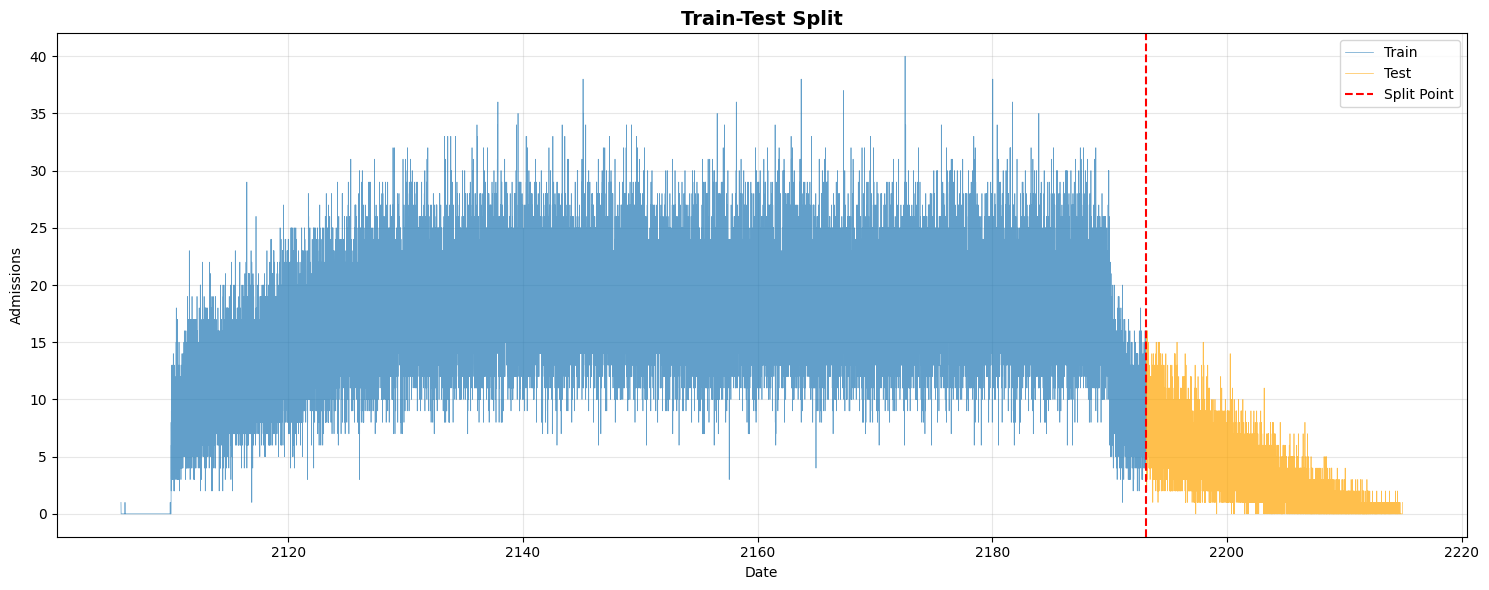

In [19]:
if len(target_series) > 0:
    train_size = int(len(target_series) * TRAIN_TEST_SPLIT)
    train_data = target_series[:train_size]
    test_data = target_series[train_size:]
    print(f"Train set: {len(train_data)} days ({train_data.index.min()} to {train_data.index.max()})")
    print(f"Test set: {len(test_data)} days ({test_data.index.min()} to {test_data.index.max()})")
    print(f"Train/Test split: {len(train_data)}/{len(test_data)} = {TRAIN_TEST_SPLIT:.1%}")
    plt.figure(figsize=(15, 6))
    plt.plot(train_data.index, train_data.values, label='Train', alpha=0.7, linewidth=0.5)
    plt.plot(test_data.index, test_data.values, label='Test', alpha=0.7, linewidth=0.5, color='orange')
    plt.axvline(x=train_data.index[-1], color='red', linestyle='--', label='Split Point')
    plt.title('Train-Test Split', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Admissions')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_plot(plt.gcf(), 'train_test_split.png', RESULTS_PATH, DRIVE_RESULTS_PATH, dpi=300, bbox_inches='tight')
    plt.show()
else:
    train_data = pd.Series(dtype=float)
    test_data = pd.Series(dtype=float)


## Enhanced ARIMA with Feature Engineering (ARIMAX)

ARIMAX extends ARIMA by adding exogenous variables (features) to improve forecast accuracy. This addresses the negative R² issue by explicitly modeling weekly patterns and holidays.


In [ ]:
# ============================================================================
# ENHANCED ARIMA WITH FEATURE ENGINEERING (ARIMAX)
# ============================================================================

arimax_model = None
arimax_forecast = None

if PMDARIMA_AVAILABLE and len(train_data) > 0:
    print("="*60)
    print("Enhanced ARIMA with Features (ARIMAX)")
    print("="*60)

    # Load pre-configured ARIMAX features from notebook 03 (from multiple locations)
    arimax_features_data = load_file('features_for_arimax.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)
    if arimax_features_data is not None:
        print("Loading ARIMAX features (created in notebook 03)...")

        # Extract exogenous features (all columns except 'admissions')
        exog_features = [col for col in arimax_features_data.columns if col != 'admissions']

        if len(exog_features) > 0:
            print(f"✓ Using {len(exog_features)} exogenous features: {exog_features}")

            # Prepare exogenous variables (aligned with train/test split)
            train_exog = arimax_features_data[exog_features][:len(train_data)]
            test_exog = arimax_features_data[exog_features][len(train_data):]

            # Align indices
            train_exog_aligned = train_exog.reindex(train_data.index, method='ffill').fillna(0)
            test_exog_aligned = test_exog.reindex(test_data.index, method='ffill').fillna(0)

            # Ensure same length
            min_len = min(len(train_data), len(train_exog_aligned))
            train_data_aligned = train_data.iloc[:min_len]
            train_exog_aligned = train_exog_aligned.iloc[:min_len]

            # Limit training data to last 5 years for speed and better recent pattern capture
            max_train_days = 1825  # 5 years (5 * 365)
            if len(train_data_aligned) > max_train_days:
                train_data_aligned = train_data_aligned.iloc[-max_train_days:]
                train_exog_aligned = train_exog_aligned.iloc[-max_train_days:]
                print(f"  Limited training data to last {max_train_days} days (~5 years) for speed")

            print(f"✓ Training ARIMAX with exogenous variables...")
            print(f"  Training data: {len(train_data_aligned)} days")
            print(f"  Exogenous variables: {train_exog_aligned.shape}")
            print(f"  Using fixed ARIMA order: (1, 0, 5) for speed and volatility capture...")

            try:
                # ============================================================
                # ARIMAX TRAINING WITH FIXED ORDER (1, 0, 5)
                # ============================================================

                # 1. Feature selection: Select most important features
                print("  Selecting most important features...")
                from sklearn.feature_selection import SelectKBest, f_regression

                # Select top features based on correlation with target
                n_features_to_select = min(15, len(exog_features))  # Use top 15 features
                selector = SelectKBest(score_func=f_regression, k=n_features_to_select)
                selector.fit(train_exog_aligned.values, train_data_aligned.values)

                # Get selected feature indices
                selected_indices = selector.get_support(indices=True)
                selected_features = [exog_features[i] for i in selected_indices]
                train_exog_selected = train_exog_aligned.iloc[:, selected_indices]
                test_exog_selected = test_exog_aligned.iloc[:, selected_indices]

                print(f"  Selected {len(selected_features)} most important features")
                print(f"  Selected features: {selected_features}")
                # Print feature scores (importance)
                feature_scores = dict(zip(selected_features, selector.scores_[selected_indices]))
                print(f"  Feature importance scores (F-statistic):")
                for feat, score in sorted(feature_scores.items(), key=lambda x: x[1], reverse=True):
                    print(f"    {feat}: {score:.2f}")

                # 2. Scale exogenous variables for better numerical stability
                from sklearn.preprocessing import StandardScaler
                exog_scaler = StandardScaler()
                train_exog_scaled = exog_scaler.fit_transform(train_exog_selected.values)
                test_exog_scaled = exog_scaler.transform(test_exog_selected.values)

                # 3. Train with fixed order (1, 0, 5) - much faster than auto_arima, more reactive to volatility
                print("  Training ARIMAX(1, 0, 5) model...")
                arimax_model = pm.ARIMA(order=(1, 0, 5),
                                       suppress_warnings=True,
                                       with_intercept=True,
                                       maxiter=ARIMA_MAX_ITER,
                                       method='lbfgs')
                arimax_model.fit(train_data_aligned.values, exogenous=train_exog_scaled)

                print(f"\n✓ ARIMAX model trained")
                print(f"ARIMA order: {arimax_model.order}")
                print(f"Model AIC: {arimax_model.aic():.2f}")
                print(f"Model BIC: {arimax_model.bic():.2f}")
                print(f"Model AICc: {arimax_model.aicc():.2f}")

                # 4. Residual diagnostics
                print(f"\n  Performing residual diagnostics...")
                try:
                    residuals = arimax_model.resid()
                    print(f"  Residual statistics:")
                    print(f"    Mean: {residuals.mean():.4f} (should be ~0)")
                    print(f"    Std: {residuals.std():.4f}")
                    print(f"    Skewness: {pd.Series(residuals).skew():.4f} (should be ~0)")
                    print(f"    Kurtosis: {pd.Series(residuals).kurtosis():.4f} (should be ~3)")

                    # Ljung-Box test for residual autocorrelation
                    from statsmodels.stats.diagnostic import acorr_ljungbox
                    lb_test = acorr_ljungbox(residuals, lags=10, return_df=True)
                    p_value = lb_test['lb_pvalue'].iloc[-1]
                    print(f"    Ljung-Box test p-value: {p_value:.4f} (should be > 0.05 for no autocorrelation)")

                    if p_value > 0.05:
                        print(f"  ✓ Residuals appear to be white noise (good!)")
                    else:
                        print(f"  ⚠️  Residuals may have autocorrelation (consider higher order)")
                except Exception as e:
                    print(f"  ⚠️  Residual diagnostics failed: {str(e)[:100]}")

                # ============================================================
                # ROLLING WINDOW FORECASTING WITH RETRAINING, BOUNDS & SMOOTHING
                # ============================================================
                # Forecast in rolling windows with periodic retraining (faster than day-by-day recursive)
                print(f"\nGenerating rolling window ARIMAX forecasts with retraining...")
                print(f"  Window size: {ARIMAX_WINDOW_SIZE} days")
                print(f"  Hybrid retraining: base={ARIMAX_BASE_RETRAIN_FREQUENCY} days, error threshold={ARIMAX_ERROR_THRESHOLD}x, min interval={ARIMAX_EARLY_RETRAIN_THRESHOLD} days")

                # Calculate bounds from training data statistics
                train_mean = train_data_aligned.mean()
                train_std = train_data_aligned.std()
                train_min = max(0, train_data_aligned.min())  # Non-negative
                train_max = min(200, train_data_aligned.max() + 2 * train_std)  # Reasonable upper bound
                # Wider bounds for predictions (use 3 std instead of 2 to allow more variation)
                wider_train_max = min(300, train_data_aligned.max() + 3 * train_std)

                print(f"  Training statistics: mean={train_mean:.2f}, std={train_std:.2f}, range=[{train_min:.2f}, {train_max:.2f}]")
                print(f"  Prediction bounds: [{train_min:.2f}, {wider_train_max:.2f}] (wider to allow more variation)")

                # Rolling window forecast with HYBRID RETRAINING (fixed intervals + error-based triggers)
                WINDOW_SIZE = ARIMAX_WINDOW_SIZE
                BASE_RETRAIN_FREQ = ARIMAX_BASE_RETRAIN_FREQUENCY if ARIMAX_BASE_RETRAIN_FREQUENCY > 0 else len(test_data) + 1  # Disable if 0
                all_forecasts_list = []
                all_conf_lower_list = []
                all_conf_upper_list = []

                # No smoothing - preserve full daily variation
                # (Smoothing removed to better capture day-to-day ups and downs)

                # Track accumulated data for retraining
                current_train_data = train_data_aligned.copy()
                current_train_exog = train_exog_scaled.copy()
                current_model = arimax_model
                days_since_retrain = 0
                last_retrain_day = 0  # Track when we last retrained

                # Error tracking for hybrid retraining
                forecast_errors = []  # Store MAE for each window
                historical_avg_error = None  # Will be calculated after first few windows
                min_windows_for_avg = 3  # Need at least 3 windows to calculate average

                # Forecast in rolling windows with progress indicator
                num_windows = (len(test_data) + WINDOW_SIZE - 1) // WINDOW_SIZE
                with tqdm(total=num_windows, desc="  ARIMAX forecasting", unit="window") as pbar:
                    for start_idx in range(0, len(test_data), WINDOW_SIZE):
                        end_idx = min(start_idx + WINDOW_SIZE, len(test_data))
                        horizon = end_idx - start_idx

                        # HYBRID RETRAINING: Check if we need to retrain (time-based OR error-based)
                        should_retrain = False
                        retrain_reason = None

                        # Time-based retraining: Check if base frequency reached
                        time_based_retrain = (BASE_RETRAIN_FREQ > 0 and days_since_retrain >= BASE_RETRAIN_FREQ)

                        # Error-based retraining: Check if error exceeds threshold (only if we have enough history)
                        error_based_retrain = False
                        if (historical_avg_error is not None and
                            len(forecast_errors) > 0 and
                            days_since_retrain >= ARIMAX_EARLY_RETRAIN_THRESHOLD):  # Minimum time between retrains
                            recent_error = forecast_errors[-1]  # Most recent window error
                            if recent_error > historical_avg_error * ARIMAX_ERROR_THRESHOLD:
                                error_based_retrain = True
                                retrain_reason = f"error ({recent_error:.2f} > {historical_avg_error * ARIMAX_ERROR_THRESHOLD:.2f})"

                        # Retrain if either condition is met
                        if time_based_retrain:
                            should_retrain = True
                            retrain_reason = "time-based (base frequency)"
                        elif error_based_retrain:
                            should_retrain = True

                        if should_retrain:
                            try:
                                # Fast retraining: refit with same order (10x faster)
                                # Get order from current model, with fallback to original
                                current_order = getattr(current_model, 'order', None)
                                if current_order is None:
                                    current_order = arimax_model.order

                                # Validate order is a tuple/list with 3 elements
                                if not isinstance(current_order, (tuple, list)) or len(current_order) != 3:
                                    current_order = arimax_model.order

                                # Ensure we have enough data for retraining
                                max_order = max(current_order) if isinstance(current_order, (tuple, list)) else 5
                                if len(current_train_data) >= max_order + 10:
                                    # Use pmdarima ARIMA with fixed order (much faster than auto_arima)
                                    # For ARIMAX (non-seasonal), don't pass seasonal_order parameter at all
                                    current_model = pm.ARIMA(order=current_order,
                                                           suppress_warnings=True,
                                                           with_intercept=True)
                                    current_model.fit(current_train_data.values,
                                                     exogenous=current_train_exog)
                                    days_since_retrain = 0
                                    last_retrain_day = start_idx
                                    if retrain_reason:
                                        print(f"    🔄 Retraining triggered: {retrain_reason}")
                            except Exception:
                                # Silently fallback to original model on retraining failure
                                current_model = arimax_model

                        # Get exogenous variables for this window
                        window_exog = test_exog_scaled[start_idx:end_idx]

                        try:
                            # Forecast this window
                            window_pred, window_conf = current_model.predict(
                                n_periods=horizon,
                                exogenous=window_exog,
                                return_conf_int=True
                            )

                            # Convert to array if needed
                            if isinstance(window_pred, (list, pd.Series)):
                                window_pred = np.array(window_pred)
                            if window_pred.ndim > 1:
                                window_pred = window_pred.flatten()

                            # Apply bounds checking (use wider bounds to allow more variation)
                            window_pred = np.clip(window_pred, train_min, wider_train_max)

                            # No smoothing applied - each window forecasts independently to preserve daily variation
                            # (Smoothing removed to better capture day-to-day ups and downs)

                            all_forecasts_list.extend(window_pred.tolist())

                            # Calculate error for this window (for hybrid retraining)
                            if start_idx < len(test_data):
                                try:
                                    window_actual = test_data.iloc[start_idx:end_idx].values
                                    if len(window_actual) == len(window_pred):
                                        # Calculate MAE for this window
                                        window_mae = np.mean(np.abs(window_actual - window_pred))
                                        forecast_errors.append(window_mae)

                                        # Update historical average error after minimum windows
                                        if len(forecast_errors) >= min_windows_for_avg:
                                            historical_avg_error = np.mean(forecast_errors)
                                except Exception:
                                    pass  # Skip error calculation if actuals not available

                            # Handle confidence intervals (use wider bounds)
                            if window_conf is not None and len(window_conf) > 0:
                                window_conf_lower = np.clip(window_conf[:, 0], train_min, wider_train_max)
                                window_conf_upper = np.clip(window_conf[:, 1], train_min, wider_train_max)
                                all_conf_lower_list.extend(window_conf_lower.tolist())
                                all_conf_upper_list.extend(window_conf_upper.tolist())
                            else:
                                # Fallback: use forecast ± std
                                window_conf_lower = np.clip(window_pred - train_std, train_min, wider_train_max)
                                window_conf_upper = np.clip(window_pred + train_std, train_min, wider_train_max)
                                all_conf_lower_list.extend(window_conf_lower.tolist())
                                all_conf_upper_list.extend(window_conf_upper.tolist())

                        except Exception as e:
                            # Fallback: use last known forecast value instead of mean (preserves trend)
                            print(f"  ⚠️  Prediction failed for window {start_idx}-{end_idx}: {str(e)[:50]}")
                            if len(all_forecasts_list) > 0:
                                # Use last forecast value (maintains trend)
                                last_forecast = all_forecasts_list[-1]
                                window_pred = np.full(horizon, last_forecast)
                            else:
                                # First window: use mean
                                window_pred = np.full(horizon, train_mean)
                            all_forecasts_list.extend(window_pred.tolist())
                            all_conf_lower_list.extend([max(train_min, window_pred[0] - train_std)] * horizon)
                            all_conf_upper_list.extend([min(wider_train_max, window_pred[0] + train_std)] * horizon)

                        # Accumulate actual values for retraining (if available)
                        if BASE_RETRAIN_FREQ > 0 and start_idx < len(test_data):
                            try:
                                # Get actual values for this window
                                window_actual = test_data.iloc[start_idx:end_idx].values
                                window_exog_actual = test_exog_scaled[start_idx:end_idx]

                                # Add to training data for next retraining
                                current_train_data = pd.concat([
                                    current_train_data,
                                    pd.Series(window_actual, index=test_data.index[start_idx:end_idx])
                                ])

                                # Add exogenous variables
                                current_train_exog = np.vstack([
                                    current_train_exog,
                                    window_exog_actual
                                ])

                                # Limit training data size to prevent memory issues (keep last 2 years)
                                max_train_size = 730  # ~2 years
                                if len(current_train_data) > max_train_size:
                                    current_train_data = current_train_data.iloc[-max_train_size:]
                                    current_train_exog = current_train_exog[-max_train_size:]

                                days_since_retrain += horizon
                            except Exception as e:
                                # If we can't accumulate, just increment days
                                days_since_retrain += horizon

                        pbar.set_description(f"  ARIMAX forecasting (days {start_idx}-{end_idx-1})")
                        pbar.update(1)

                # Create forecast series
                arimax_forecast = pd.Series(all_forecasts_list[:len(test_data)], index=test_data.index[:len(all_forecasts_list)])

                # Create confidence intervals if available
                conf_int = None
                if len(all_conf_lower_list) > 0 and len(all_conf_upper_list) > 0:
                    conf_int = np.column_stack([
                        all_conf_lower_list[:len(test_data)],
                        all_conf_upper_list[:len(test_data)]
                    ])

                # Extend if needed
                if len(test_data) > len(arimax_forecast):
                    last_value = arimax_forecast.iloc[-1]
                    extension = pd.Series([last_value] * (len(test_data) - len(arimax_forecast)),
                                        index=test_data.index[len(arimax_forecast):])
                    arimax_forecast = pd.concat([arimax_forecast, extension])

                print(f"✓ ARIMAX forecast generated for {len(arimax_forecast)} days using rolling windows")

                # Save model, scaler, feature selector, and selected features
                save_file(arimax_model, 'arimax_model.pkl', MODELS_PATH, DRIVE_MODELS_PATH)
                save_file(exog_scaler, 'arimax_exog_scaler.pkl', MODELS_PATH, DRIVE_MODELS_PATH)
                save_file(selector, 'arimax_feature_selector.pkl', MODELS_PATH, DRIVE_MODELS_PATH)
                save_file(selected_features, 'arimax_selected_features.pkl', MODELS_PATH, DRIVE_MODELS_PATH)

                arimax_forecast_df = pd.DataFrame({'admissions': arimax_forecast.values},
                                                 index=arimax_forecast.index)
                save_file(arimax_forecast_df, 'arimax_forecast.csv', MODELS_PATH, DRIVE_MODELS_PATH)

                # Plot
                plt.figure(figsize=(15, 6))
                plt.plot(train_data.index[-90:], train_data.values[-90:], label='Train', alpha=0.7)
                plt.plot(test_data.index, test_data.values, label='Actual', color='black', linewidth=2)
                plt.plot(arimax_forecast.index, arimax_forecast.values,
                        label='ARIMAX Forecast (with features)', linestyle='--', color='blue')
                if conf_int is not None and len(conf_int) > 0:
                    forecast_len = len(arimax_forecast) # Define forecast_len here
                    conf_int_extended = np.vstack([
                        conf_int,
                        np.tile(conf_int[-1], (len(test_data) - forecast_len, 1))
                    ]) if len(test_data) > forecast_len else conf_int
                    plt.fill_between(arimax_forecast.index, conf_int_extended[:, 0],
                                   conf_int_extended[:, 1], alpha=0.2, color='blue',
                                   label='95% Confidence Interval')
                plt.title('ARIMAX Model Forecast (with Exogenous Features)',
                         fontsize=14, fontweight='bold')
                plt.xlabel('Date')
                plt.ylabel('Admissions')
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                save_plot(plt.gcf(), 'arimax_forecast.png', RESULTS_PATH, DRIVE_RESULTS_PATH,
                         dpi=300, bbox_inches='tight')
                plt.show()

            except Exception as e:
                print(f"ARIMAX model training failed: {e}")
                import traceback
                traceback.print_exc()
        else:
            print("⚠️  No suitable exogenous features found for ARIMAX")
    else:
        print("⚠️  ARIMAX features file not found - ARIMAX requires feature-engineered data")
        print("   Run notebook 03 to create feature sets")
else:
    print("ARIMAX skipped (pmdarima not available or no data)")

Enhanced ARIMA with Features (ARIMAX)
Loading ARIMAX features (created in notebook 03)...
✓ Using 5 exogenous features: ['day_of_year_sin', 'day_of_year_cos', 'is_weekend', 'is_holiday', 'is_holiday_weekend']
  Limited training data to last 1825 days (~5 years) for speed
✓ Training ARIMAX with exogenous variables...
  Training data: 1825 days
  Exogenous variables: (1825, 5)
  Using fixed ARIMA order: (2, 0, 4) for speed and volatility capture...
  Selecting most important features...
  Selected 5 most important features
  Training ARIMAX(2, 0, 4) model...

✓ ARIMAX model trained
ARIMA order: (2, 0, 4)
Model AIC: 9876.11
Model BIC: 9920.18
Model AICc: 9876.19

  Performing residual diagnostics...
  Residual statistics:
    Mean: 0.1294 (should be ~0)
    Std: 3.6057
    Skewness: 0.3218 (should be ~0)
    Kurtosis: 0.2077 (should be ~3)
    Ljung-Box test p-value: 0.2598 (should be > 0.05 for no autocorrelation)
  ✓ Residuals appear to be white noise (good!)

Generating rolling window 

  ARIMAX forecasting (days 35-41):   0%|          | 5/1140 [00:01<07:04,  2.67window/s]

    🔄 Retraining triggered: time-based (base frequency)


  ARIMAX forecasting (days 56-62):   1%|          | 8/1140 [00:02<05:32,  3.41window/s]

    🔄 Retraining triggered: time-based (base frequency)


...

    🔄 Retraining triggered: time-based (base frequency)


  ARIMAX forecasting (days 4543-4549):  57%|█████▋    | 649/1140 [05:26<03:21,  2.44window/s]

    🔄 Retraining triggered: time-based (base frequency)


  ARIMAX forecasting (days 4564-4570):  57%|█████▋    | 652/1140 [05:27<03:16,  2.49window/s]

    🔄 Retraining triggered: time-based (base frequency)


## Enhanced SARIMA with Feature Engineering (SARIMAX)

SARIMAX combines seasonal ARIMA with exogenous variables. This should outperform regular SARIMA by explicitly modeling day-of-week and holiday effects.


In [ ]:
# ============================================================================
# ENHANCED SARIMA WITH FEATURE ENGINEERING (SARIMAX)
# ============================================================================

sarimax_model = None
sarimax_forecast = None

if PMDARIMA_AVAILABLE and len(train_data) > 0 and len(train_data) >= 365:
    print("="*60)
    print("Enhanced SARIMA with Features (SARIMAX)")
    print("="*60)

    # Load pre-configured SARIMAX features from notebook 03 (from multiple locations)
    sarimax_features_data = load_file('features_for_arimax.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)
    if sarimax_features_data is not None:
        print("Loading SARIMAX features (created in notebook 03)...")

        # Extract exogenous features (all columns except 'admissions')
        exog_features = [col for col in sarimax_features_data.columns if col != 'admissions']

        if len(exog_features) > 0:
            print(f"✓ Using {len(exog_features)} exogenous features: {exog_features}")

            # Prepare exogenous variables (aligned with train/test split)
            train_exog = sarimax_features_data[exog_features][:len(train_data)]
            test_exog = sarimax_features_data[exog_features][len(train_data):]

            # Align indices
            train_exog_aligned = train_exog.reindex(train_data.index, method='ffill').fillna(0)
            test_exog_aligned = test_exog.reindex(test_data.index, method='ffill').fillna(0)

            # Ensure same length
            min_len = min(len(train_data), len(train_exog_aligned))
            train_data_aligned = train_data.iloc[:min_len]
            train_exog_aligned = train_exog_aligned.iloc[:min_len]

            # Limit training data to last 5 years for speed and better recent pattern capture
            max_train_days = 1825  # 5 years (5 * 365)
            if len(train_data_aligned) > max_train_days:
                train_data_aligned = train_data_aligned.iloc[-max_train_days:]
                train_exog_aligned = train_exog_aligned.iloc[-max_train_days:]
                print(f"  Limited training data to last {max_train_days} days (~5 years) for speed")

            print(f"✓ Training SARIMAX with weekly seasonality and features...")
            print(f"  Training data: {len(train_data_aligned)} days")
            print(f"  Using fixed SARIMA order: (1, 0, 5) with seasonal order (0, 0, 1, 7) for speed and volatility capture...")

            try:
                # ============================================================
                # SARIMAX TRAINING WITH FIXED ORDER (1, 0, 5) x (0, 0, 1, 7)
                # ============================================================

                # 1. Feature selection: Select most important features
                print("  Selecting most important features...")
                from sklearn.feature_selection import SelectKBest, f_regression

                # Select top features based on correlation with target
                n_features_to_select = min(15, len(exog_features))  # Use top 15 features
                selector = SelectKBest(score_func=f_regression, k=n_features_to_select)
                selector.fit(train_exog_aligned.values, train_data_aligned.values)

                # Get selected feature indices
                selected_indices = selector.get_support(indices=True)
                selected_features = [exog_features[i] for i in selected_indices]
                train_exog_selected = train_exog_aligned.iloc[:, selected_indices]
                test_exog_selected = test_exog_aligned.iloc[:, selected_indices]

                print(f"  Selected {len(selected_features)} most important features")
                print(f"  Selected features: {selected_features}")
                # Print feature scores (importance)
                feature_scores = dict(zip(selected_features, selector.scores_[selected_indices]))
                print(f"  Feature importance scores (F-statistic):")
                for feat, score in sorted(feature_scores.items(), key=lambda x: x[1], reverse=True):
                    print(f"    {feat}: {score:.2f}")

                # 2. Scale exogenous variables for better numerical stability
                from sklearn.preprocessing import StandardScaler
                exog_scaler = StandardScaler()
                train_exog_scaled = exog_scaler.fit_transform(train_exog_selected.values)
                test_exog_scaled = exog_scaler.transform(test_exog_selected.values)

                # 3. Train with fixed order (1, 0, 5) x (0, 0, 1, 7) - much faster than auto_arima, more reactive to volatility
                print("  Training SARIMAX(1, 0, 5) x (0, 0, 1, 7) model...")
                sarimax_model = pm.ARIMA(order=(1, 0, 5),
                                        seasonal_order=(0, 0, 1, 7),  # Weekly seasonality
                                        suppress_warnings=True,
                                        with_intercept=True,
                                        maxiter=SARIMA_MAX_ITER,
                                        method='lbfgs')
                sarimax_model.fit(train_data_aligned.values, exogenous=train_exog_scaled)

                print(f"\n✓ SARIMAX model trained")
                print(f"SARIMA order: {sarimax_model.order}")
                print(f"Seasonal order: {sarimax_model.seasonal_order}")
                print(f"Model AIC: {sarimax_model.aic():.2f}")
                print(f"Model BIC: {sarimax_model.bic():.2f}")
                print(f"Model AICc: {sarimax_model.aicc():.2f}")

                # 4. Residual diagnostics
                print(f"\n  Performing residual diagnostics...")
                try:
                    residuals = sarimax_model.resid()
                    print(f"  Residual statistics:")
                    print(f"    Mean: {residuals.mean():.4f} (should be ~0)")
                    print(f"    Std: {residuals.std():.4f}")
                    print(f"    Skewness: {pd.Series(residuals).skew():.4f} (should be ~0)")
                    print(f"    Kurtosis: {pd.Series(residuals).kurtosis():.4f} (should be ~3)")

                    # Ljung-Box test for residual autocorrelation
                    from statsmodels.stats.diagnostic import acorr_ljungbox
                    lb_test = acorr_ljungbox(residuals, lags=10, return_df=True)
                    p_value = lb_test['lb_pvalue'].iloc[-1]
                    print(f"    Ljung-Box test p-value: {p_value:.4f} (should be > 0.05 for no autocorrelation)")

                    if p_value > 0.05:
                        print(f"  ✓ Residuals appear to be white noise (good!)")
                    else:
                        print(f"  ⚠️  Residuals may have autocorrelation (consider higher order)")
                except Exception as e:
                    print(f"  ⚠️  Residual diagnostics failed: {str(e)[:100]}")

                # ============================================================
                # ROLLING WINDOW FORECASTING WITH RETRAINING, BOUNDS & SMOOTHING
                # ============================================================
                # Forecast in rolling windows with periodic retraining (faster than day-by-day recursive)
                print(f"\nGenerating rolling window SARIMAX forecasts with retraining...")
                print(f"  Window size: {SARIMAX_WINDOW_SIZE} days")
                print(f"  Hybrid retraining: base={SARIMAX_BASE_RETRAIN_FREQUENCY} days, error threshold={SARIMAX_ERROR_THRESHOLD}x, min interval={SARIMAX_EARLY_RETRAIN_THRESHOLD} days")

                # Calculate bounds from training data statistics
                train_mean = train_data_aligned.mean()
                train_std = train_data_aligned.std()
                train_min = max(0, train_data_aligned.min())  # Non-negative
                train_max = min(200, train_data_aligned.max() + 2 * train_std)  # Reasonable upper bound
                wider_train_max = min(300, train_data_aligned.max() + 3 * train_std)  # Wider bounds for more variation

                print(f"  Training statistics: mean={train_mean:.2f}, std={train_std:.2f}, range=[{train_min:.2f}, {wider_train_max:.2f}]")

                # Rolling window forecast with HYBRID RETRAINING (fixed intervals + error-based triggers)
                WINDOW_SIZE = SARIMAX_WINDOW_SIZE
                BASE_RETRAIN_FREQ = SARIMAX_BASE_RETRAIN_FREQUENCY if SARIMAX_BASE_RETRAIN_FREQUENCY > 0 else len(test_data) + 1  # Disable if 0
                all_forecasts_list = []
                all_conf_lower_list = []
                all_conf_upper_list = []

                # No smoothing - preserve full daily variation
                # (Smoothing removed to better capture day-to-day ups and downs)

                # Track accumulated data for retraining
                current_train_data = train_data_aligned.copy()
                current_train_exog = train_exog_scaled.copy()
                current_model = sarimax_model
                days_since_retrain = 0
                last_retrain_day = 0  # Track when we last retrained

                # Error tracking for hybrid retraining
                forecast_errors = []  # Store MAE for each window
                historical_avg_error = None  # Will be calculated after first few windows
                min_windows_for_avg = 3  # Need at least 3 windows to calculate average

                # Forecast in rolling windows with progress indicator
                num_windows = (len(test_data) + WINDOW_SIZE - 1) // WINDOW_SIZE
                with tqdm(total=num_windows, desc="  SARIMAX forecasting", unit="window") as pbar:
                    for start_idx in range(0, len(test_data), WINDOW_SIZE):
                        end_idx = min(start_idx + WINDOW_SIZE, len(test_data))
                        horizon = end_idx - start_idx

                        # HYBRID RETRAINING: Check if we need to retrain (time-based OR error-based)
                        should_retrain = False
                        retrain_reason = None

                        # Time-based retraining: Check if base frequency reached
                        time_based_retrain = (BASE_RETRAIN_FREQ > 0 and days_since_retrain >= BASE_RETRAIN_FREQ)

                        # Error-based retraining: Check if error exceeds threshold (only if we have enough history)
                        error_based_retrain = False
                        if (historical_avg_error is not None and
                            len(forecast_errors) > 0 and
                            days_since_retrain >= SARIMAX_EARLY_RETRAIN_THRESHOLD):  # Minimum time between retrains
                            recent_error = forecast_errors[-1]  # Most recent window error
                            if recent_error > historical_avg_error * SARIMAX_ERROR_THRESHOLD:
                                error_based_retrain = True
                                retrain_reason = f"error ({recent_error:.2f} > {historical_avg_error * SARIMAX_ERROR_THRESHOLD:.2f})"

                        # Retrain if either condition is met
                        if time_based_retrain:
                            should_retrain = True
                            retrain_reason = "time-based (base frequency)"
                        elif error_based_retrain:
                            should_retrain = True

                        if should_retrain:
                            try:
                                # Fast retraining: refit with same order (10x faster)
                                # Get orders from current model, with fallback to original
                                current_order = getattr(current_model, 'order', None)
                                current_seasonal_order = getattr(current_model, 'seasonal_order', None)

                                # Validate and fallback if needed
                                if current_order is None or not isinstance(current_order, (tuple, list)) or len(current_order) != 3:
                                    current_order = sarimax_model.order
                                if current_seasonal_order is None or not isinstance(current_seasonal_order, (tuple, list)) or len(current_seasonal_order) != 4:
                                    current_seasonal_order = sarimax_model.seasonal_order

                                # Ensure we have enough data for retraining
                                max_order = max(current_order) if isinstance(current_order, (tuple, list)) else 5
                                max_seasonal = max(current_seasonal_order[:3]) if isinstance(current_seasonal_order, (tuple, list)) and len(current_seasonal_order) >= 3 else 5
                                min_data_needed = max(max_order, max_seasonal) + 10

                                if len(current_train_data) >= min_data_needed:
                                    # Use pmdarima ARIMA with fixed orders (much faster than auto_arima)
                                    current_model = pm.ARIMA(order=current_order,
                                                           seasonal_order=current_seasonal_order,
                                                           suppress_warnings=True,
                                                           with_intercept=True)
                                    current_model.fit(current_train_data.values,
                                                     exogenous=current_train_exog)
                                    days_since_retrain = 0
                                    last_retrain_day = start_idx
                                    if retrain_reason:
                                        print(f"    🔄 Retraining triggered: {retrain_reason}")
                            except Exception:
                                # Silently fallback to original model on retraining failure
                                current_model = sarimax_model

                        # Get exogenous variables for this window
                        window_exog = test_exog_scaled[start_idx:end_idx]

                        try:
                            # Forecast this window
                            window_pred, window_conf = current_model.predict(
                                n_periods=horizon,
                                exogenous=window_exog,
                                return_conf_int=True
                            )

                            # Convert to array if needed
                            if isinstance(window_pred, (list, pd.Series)):
                                window_pred = np.array(window_pred)
                            if window_pred.ndim > 1:
                                window_pred = window_pred.flatten()

                            # Apply bounds checking
                            window_pred = np.clip(window_pred, train_min, wider_train_max)

                            # No smoothing - preserve full daily variation
                            all_forecasts_list.extend(window_pred.tolist())

                            # Calculate error for this window (for hybrid retraining)
                            if start_idx < len(test_data):
                                try:
                                    window_actual = test_data.iloc[start_idx:end_idx].values
                                    if len(window_actual) == len(window_pred):
                                        # Calculate MAE for this window
                                        window_mae = np.mean(np.abs(window_actual - window_pred))
                                        forecast_errors.append(window_mae)

                                        # Update historical average error after minimum windows
                                        if len(forecast_errors) >= min_windows_for_avg:
                                            historical_avg_error = np.mean(forecast_errors)
                                except Exception:
                                    pass  # Skip error calculation if actuals not available

                            # Handle confidence intervals (use wider bounds)
                            if window_conf is not None and len(window_conf) > 0:
                                window_conf_lower = np.clip(window_conf[:, 0], train_min, wider_train_max)
                                window_conf_upper = np.clip(window_conf[:, 1], train_min, wider_train_max)
                                all_conf_lower_list.extend(window_conf_lower.tolist())
                                all_conf_upper_list.extend(window_conf_upper.tolist())
                            else:
                                # Fallback: use forecast ± std
                                window_conf_lower = np.clip(window_pred - train_std, train_min, wider_train_max)
                                window_conf_upper = np.clip(window_pred + train_std, train_min, wider_train_max)
                                all_conf_lower_list.extend(window_conf_lower.tolist())
                                all_conf_upper_list.extend(window_conf_upper.tolist())

                        except Exception as e:
                            # Fallback: use last known forecast value instead of mean (preserves trend)
                            print(f"  ⚠️  Prediction failed for window {start_idx}-{end_idx}: {str(e)[:50]}")
                            if len(all_forecasts_list) > 0:
                                last_forecast = all_forecasts_list[-1]
                                window_pred = np.full(horizon, last_forecast)
                            else:
                                window_pred = np.full(horizon, train_mean)
                            all_forecasts_list.extend(window_pred.tolist())
                            all_conf_lower_list.extend([max(train_min, window_pred[0] - train_std)] * horizon)
                            all_conf_upper_list.extend([min(wider_train_max, window_pred[0] + train_std)] * horizon)

                        # Accumulate actual values for retraining (if available)
                        if BASE_RETRAIN_FREQ > 0 and start_idx < len(test_data):
                            try:
                                # Get actual values for this window
                                window_actual = test_data.iloc[start_idx:end_idx].values
                                window_exog_actual = test_exog_scaled[start_idx:end_idx]

                                # Add to training data for next retraining
                                current_train_data = pd.concat([
                                    current_train_data,
                                    pd.Series(window_actual, index=test_data.index[start_idx:end_idx])
                                ])

                                # Add exogenous variables
                                current_train_exog = np.vstack([
                                    current_train_exog,
                                    window_exog_actual
                                ])

                                # Limit training data size to prevent memory issues (keep last 2 years)
                                max_train_size = 730  # ~2 years
                                if len(current_train_data) > max_train_size:
                                    current_train_data = current_train_data.iloc[-max_train_size:]
                                    current_train_exog = current_train_exog[-max_train_size:]

                                days_since_retrain += horizon
                            except Exception as e:
                                # If we can't accumulate, just increment days
                                days_since_retrain += horizon

                        pbar.set_description(f"  SARIMAX forecasting (days {start_idx}-{end_idx-1})")
                        pbar.update(1)

                # Create forecast series
                sarimax_forecast = pd.Series(all_forecasts_list[:len(test_data)], index=test_data.index[:len(all_forecasts_list)])

                # Create confidence intervals if available
                conf_int = None
                if len(all_conf_lower_list) > 0 and len(all_conf_upper_list) > 0:
                    conf_int = np.column_stack([
                        all_conf_lower_list[:len(test_data)],
                        all_conf_upper_list[:len(test_data)]
                    ])

                # Extend if needed
                if len(test_data) > len(sarimax_forecast):
                    last_value = sarimax_forecast.iloc[-1]
                    extension = pd.Series([last_value] * (len(test_data) - len(sarimax_forecast)),
                                        index=test_data.index[len(sarimax_forecast):])
                    sarimax_forecast = pd.concat([sarimax_forecast, extension])

                print(f"✓ SARIMAX forecast generated for {len(sarimax_forecast)} days using rolling windows")

                # Save model, scaler, feature selector, and selected features
                save_file(sarimax_model, 'sarimax_model.pkl', MODELS_PATH, DRIVE_MODELS_PATH)
                save_file(exog_scaler, 'sarimax_exog_scaler.pkl', MODELS_PATH, DRIVE_MODELS_PATH)
                save_file(selector, 'sarimax_feature_selector.pkl', MODELS_PATH, DRIVE_MODELS_PATH)
                save_file(selected_features, 'sarimax_selected_features.pkl', MODELS_PATH, DRIVE_MODELS_PATH)

                sarimax_forecast_df = pd.DataFrame({'admissions': sarimax_forecast.values},
                                                  index=sarimax_forecast.index)
                save_file(sarimax_forecast_df, 'sarimax_forecast.csv', MODELS_PATH, DRIVE_MODELS_PATH)

                # Plot
                plt.figure(figsize=(15, 6))
                plt.plot(train_data.index[-90:], train_data.values[-90:], label='Train', alpha=0.7)
                plt.plot(test_data.index, test_data.values, label='Actual', color='black', linewidth=2)
                plt.plot(sarimax_forecast.index, sarimax_forecast.values,
                        label='SARIMAX Forecast (weekly seasonality + features)',
                        linestyle='--', color='green')
                if conf_int is not None and len(conf_int) > 0:
                    forecast_len = len(sarimax_forecast)  # Define forecast_len here
                    conf_int_extended = np.vstack([
                        conf_int,
                        np.tile(conf_int[-1], (len(test_data) - forecast_len, 1))
                    ]) if len(test_data) > forecast_len else conf_int
                    plt.fill_between(sarimax_forecast.index, conf_int_extended[:, 0],
                                   conf_int_extended[:, 1], alpha=0.2, color='green',
                                   label='95% Confidence Interval')
                plt.title('SARIMAX Model Forecast (Weekly Seasonality + Features)',
                         fontsize=14, fontweight='bold')
                plt.xlabel('Date')
                plt.ylabel('Admissions')
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                save_plot(plt.gcf(), 'sarimax_forecast.png', RESULTS_PATH, DRIVE_RESULTS_PATH,
                         dpi=300, bbox_inches='tight')
                plt.show()

            except Exception as e:
                print(f"SARIMAX model training failed: {e}")
                import traceback
                traceback.print_exc()
        else:
            print("⚠️  No suitable exogenous features found for SARIMAX")
    else:
        print("⚠️  SARIMAX features file not found - SARIMAX requires feature-engineered data")
        print("   Run notebook 03 to create feature sets")
else:
    if not PMDARIMA_AVAILABLE:
        print("SARIMAX skipped (pmdarima not available)")
    elif len(train_data) < 365:
        print("SARIMAX skipped (need at least 365 days of data)")
    else:
        print("SARIMAX skipped (no data)")



## Model Evaluation

Calculate basic evaluation metrics to assess ARIMAX and SARIMAX model performance.


In [ ]:
# ============================================================================
# ARIMAX & SARIMAX MODEL EVALUATION METRICS
# ============================================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def calculate_mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error."""
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

results = {}

# Evaluate ARIMAX
if arimax_forecast is not None and len(test_data) > 0:
    forecast_aligned = arimax_forecast.reindex(test_data.index)
    mask = ~(forecast_aligned.isna() | test_data.isna())
    if mask.sum() > 0:
        y_true = test_data[mask].values
        y_pred = forecast_aligned[mask].values
        results['ARIMAX'] = {
            'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'MAPE': calculate_mape(y_true, y_pred),
            'R²': r2_score(y_true, y_pred)
        }

# Evaluate SARIMAX
if sarimax_forecast is not None and len(test_data) > 0:
    forecast_aligned = sarimax_forecast.reindex(test_data.index)
    mask = ~(forecast_aligned.isna() | test_data.isna())
    if mask.sum() > 0:
        y_true = test_data[mask].values
        y_pred = forecast_aligned[mask].values
        results['SARIMAX'] = {
            'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'MAPE': calculate_mape(y_true, y_pred),
            'R²': r2_score(y_true, y_pred)
        }

# Display results
if results:
    print("="*70)
    print("ARIMAX & SARIMAX MODELS - EVALUATION METRICS")
    print("="*70)
    print(f"\nTest period: {len(test_data)} days")
    print(f"Date range: {test_data.index.min()} to {test_data.index.max()}\n")

    print(f"{'Model':<25} {'MAE':<10} {'RMSE':<10} {'MAPE (%)':<12} {'R²':<10}")
    print("-"*70)
    for model_name, metrics in results.items():
        mape_str = f"{metrics['MAPE']:.2f}" if not np.isnan(metrics['MAPE']) else "N/A"
        print(f"{model_name:<25} {metrics['MAE']:<10.2f} {metrics['RMSE']:<10.2f} {mape_str:<12} {metrics['R²']:<10.4f}")

    # Find best model
    if len(results) > 1:
        print("\n" + "="*70)
        print("BEST MODEL BY METRIC:")
        print("="*70)
        best_mae = min(results.items(), key=lambda x: x[1]['MAE'])
        best_rmse = min(results.items(), key=lambda x: x[1]['RMSE'])
        best_mape = min([(k, v) for k, v in results.items() if not np.isnan(v['MAPE'])],
                       key=lambda x: x[1]['MAPE'], default=(None, None))
        best_r2 = max(results.items(), key=lambda x: x[1]['R²'])

        print(f"Best MAE:  {best_mae[0]} ({best_mae[1]['MAE']:.2f})")
        print(f"Best RMSE: {best_rmse[0]} ({best_rmse[1]['RMSE']:.2f})")
        if best_mape[0]:
            print(f"Best MAPE: {best_mape[0]} ({best_mape[1]['MAPE']:.2f}%)")
        print(f"Best R²:  {best_r2[0]} ({best_r2[1]['R²']:.4f})")

    # Save results
    results_df = pd.DataFrame(results).T
    save_file(results_df, 'arimax_sarimax_evaluation.csv', MODELS_PATH, DRIVE_MODELS_PATH)
    print(f"\n✓ Evaluation metrics saved to arimax_sarimax_evaluation.csv")
else:
    print("⚠️  Cannot evaluate: No forecasts available")
